# 02 - Pré-processamento e Modelagem

Este notebook aplica a seleção de variáveis definida na EDA e treina modelos de regressão para prever o `indice_perda_real`.

A comparação inclui uma referência baseada no `indice_perda_orcado`, uma regressão linear e um Random Forest.

As colunas pós-execução e os identificadores administrativos ficam fora da modelagem para evitar vazamento de dados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [3]:
project_path = Path("..")
raw_data_path = project_path / "data" / "raw"
models_path = project_path / "models"

df = pd.read_csv(raw_data_path / "perda_material.csv")
df.head()

,registro_id,obra_id,data_registro,requisicao_id,empreiteiro_id,fornecedor_id,tipo_obra,fase_obra,ambiente,servico,...,pressao_prazo,qtd_frentes_simultaneas,quantidade_real_consumida,quantidade_sobra_reaproveitavel,quantidade_perdida_nao_reaproveitavel,houve_retrabalho_real,motivo_principal_perda,indice_perda_real,custo_perda_real,risco_perda_real
0,REG_00001,OBRA_020,2025-07-12,REQ_01849,EMP_014,FORN_040,industrial,fechamento,interno,impermeabilizacao,...,media,2,2297.46,67.78,216.62,0,recorte_ajuste,0.1413,8699.36,alto
1,REG_00002,OBRA_003,2025-02-09,REQ_01673,EMP_029,FORN_040,comercial,acabamento,interno,esquadrias_madeira,...,media,1,2651.13,104.37,214.92,1,retrabalho,0.1369,202158.16,alto
2,REG_00003,OBRA_018,2025-04-23,REQ_02051,EMP_035,FORN_005,industrial,fechamento,interno,vedacao_alvenaria,...,media,5,1809.75,53.78,157.03,0,consumo_acima_previsto,0.1318,471.10,alto
3,REG_00004,OBRA_014,2025-07-31,REQ_00070,EMP_033,FORN_008,industrial,estrutura,externo,estrutura_concreto,...,media,3,2184.37,49.40,225.61,0,consumo_acima_previsto,0.1440,15731.87,alto
4,REG_00005,OBRA_013,2025-02-21,REQ_01355,EMP_001,FORN_046,comercial,estrutura,externo,estrutura_concreto,...,alta,4,2214.72,46.52,119.08,0,recorte_ajuste,0.0808,37108.88,medio


## 1. Seleção de variáveis

A seleção de variáveis segue as decisões tomadas na EDA. Identificadores, colunas pós-execução e variáveis derivadas da perda real são removidos da modelagem.

In [4]:
# Colunas de identificação: úteis para rastreabilidade, mas não para previsão
colunas_identificacao = [
    "registro_id",
    "obra_id",
    "data_registro",
    "requisicao_id",
    "empreiteiro_id",
    "fornecedor_id"
]
# Colunas conhecidas apenas após a execução do serviço
colunas_pos_execucao = [
    "quantidade_real_consumida",
    "quantidade_sobra_reaproveitavel",
    "quantidade_perdida_nao_reaproveitavel",
    "houve_retrabalho_real",
    "motivo_principal_perda"
]
# Colunas calculadas, auxiliares ou derivadas do alvo
colunas_calculadas_ou_auxiliares = [
    "quantidade_orcada",
    "custo_perda_real",
    "risco_perda_real",
]
# Outras colunas removidas por decisão de modelagem
colunas_removidas = [
    "compra_emergencial",
    "unidade_medida"
]

In [5]:
# Separando as variáveis de entrada do modelo e a variável-alvo
alvo = "indice_perda_real"

colunas_excluidas = (
    colunas_identificacao
    + colunas_pos_execucao
    + colunas_calculadas_ou_auxiliares
    + colunas_removidas
)

features = [coluna for coluna in df.columns if coluna not in colunas_excluidas + [alvo]]

X = df[features]
y = df[alvo]

In [ ]:
# Conferindo os tipos de variáveis de entrada
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tipo_obra                 5000 non-null   str    
 1   fase_obra                 5000 non-null   str    
 2   ambiente                  5000 non-null   str    
 3   servico                   5000 non-null   str    
 4   complexidade_execucao     5000 non-null   str    
 5   necessidade_corte_ajuste  5000 non-null   str    
 6   material                  5000 non-null   str    
 7   tipo_item_material        5000 non-null   str    
 8   material_fragil           5000 non-null   int64  
 9   material_modular          5000 non-null   int64  
 10  custo_unitario            5000 non-null   float64
 11  quantidade_teorica        5000 non-null   float64
 12  indice_perda_orcado       5000 non-null   float64
 13  pressao_prazo             5000 non-null   str    
 14  qtd_frentes_simulta

## 2. Pré-processamento

As variáveis de entrada misturam colunas categóricas, numéricas e binárias.

As colunas categóricas serão transformadas com One-Hot Encoding. As colunas numéricas e binárias já estão em formato compatível com os modelos e serão mantidas diretamente no pipeline.


In [6]:
# Separando as colunas por tipo de tratamento no pré-processamento
colunas_categoricas = X.select_dtypes(include="object").columns.tolist()

colunas_binarias = ["material_fragil", "material_modular"]

colunas_numericas = [
    coluna for coluna in X.select_dtypes(include = ["int64", "float64"]).columns
    if coluna not in colunas_binarias
]

In [7]:
# Aplicando One-Hot Encoding nas categóricas e mantendo numéricas/binárias
preprocessador = ColumnTransformer(
    transformers = [
        ("categoricas", OneHotEncoder(handle_unknown = "ignore"), colunas_categoricas),
        ("numericas", "passthrough", colunas_numericas),
        ("binarias", "passthrough", colunas_binarias)
    ]
)

## 3. Separação entre treino e teste

Antes de treinar os modelos, a base será dividida em conjunto de treino e teste.

O conjunto de treino será usado para ajustar os modelos, enquanto o conjunto de teste ficará separado para avaliar o desempenho em dados que o modelo ainda não viu.

In [ ]:
# Separando a base em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 579)

## 4. Treinamento dos modelos

Nesta etapa, comparo uma referência simples baseada no índice orçado com dois modelos de regressão:

* `LinearRegression`, como modelo base mais simples;
* `RandomForestRegressor`, como modelo capaz de capturar relações não lineares entre as variáveis.

Os modelos são montados em `Pipeline`, combinando o pré-processamento das variáveis com o algoritmo de regressão.

In [ ]:
# Função para calcular principais métricas de regressão
def avaliar_modelo(nome_modelo, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
# Criando pipelines com o mesmo pré-processamento para cada modelo
modelo_linear = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", LinearRegression())
    ]
)

modelo_random_forest = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", RandomForestRegressor(
            n_estimators = 100,
            random_state = 579,
            n_jobs = -1
        ))
    ]
)

In [ ]:
# Treinando os modelos com o conjunto de treino
modelo_linear.fit(X_treino, y_treino)

modelo_random_forest.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['tipo_obra','fase_obra','ambiente',...,'indice_perda_orcado', 'pressao_prazo','qtd_frentes_simultaneas']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wi

In [ ]:
# Gerando previsões no conjunto de teste
pred_linear = modelo_linear.predict(X_teste)

pred_random_forest = modelo_random_forest.predict(X_teste)

In [ ]:
# Baseline: usando o índice de perda orçado como previsão direta
pred_orcado = X_teste["indice_perda_orcado"]

In [ ]:
# Comparando o desempenho do baseline e dos modelos treinados
resultados = [
    avaliar_modelo("Índice orçado", y_teste, pred_orcado),
    avaliar_modelo("Regressão Linear", y_teste, pred_linear),
    avaliar_modelo("Random Forest", y_teste, pred_random_forest)
]

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,modelo,MAE,RMSE,R2
0,Índice orçado,0.051022,0.059070,-2.087832
1,Regressão Linear,0.017495,0.023152,0.525634
2,Random Forest,0.019838,0.025656,0.417496


O uso direto do `indice_perda_orcado` apresentou erro maior que os modelos treinados.

Isso indica que variáveis como serviço, material, necessidade de corte/ajuste e contexto operacional acrescentam informação relevante para estimar a perda real.

## 5. Análise das previsões

Após a comparação das métricas, o modelo treinado com menor MAE foi usado para a análise visual das previsões.

Os gráficos abaixo comparam valores reais, valores previstos e resíduos do modelo.

In [ ]:
# Selecionando o modelo com melhor desempenho(menor MAE)
melhor_linha = resultados_modelos[
    resultados_modelos["modelo"] != "Índice orçado"
].sort_values("MAE").iloc[0]

nome_melhor_modelo = melhor_linha["modelo"]

if nome_melhor_modelo == "Regressão Linear":
    melhor_modelo = modelo_linear
    y_pred_melhor = pred_linear
else:
    melhor_modelo = modelo_random_forest
    y_pred_melhor = pred_random_forest
nome_melhor_modelo

'Regressão Linear'

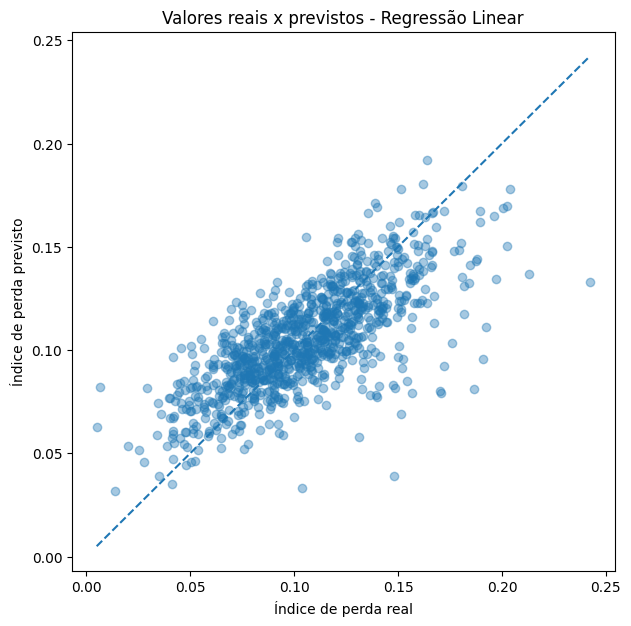

In [ ]:
# Comparando valores reais e previstos pelo modelo escolhido
plt.figure(figsize = (7, 7))

plt.scatter(y_teste, y_pred_melhor, alpha = 0.4)

limite_min = min(y_teste.min(), y_pred_melhor.min())
limite_max = max(y_teste.max(), y_pred_melhor.max())

plt.plot([limite_min, limite_max], [limite_min, limite_max], linestyle = "--")

plt.title(f"Valores reais x previstos - {nome_melhor_modelo}")
plt.xlabel("Índice de perda real")
plt.ylabel("Índice de perda previsto")
plt.show()

In [ ]:
# Calculando os resíduos do modelo
residuos = y_teste - y_pred_melhor
residuos.describe()

count    1000.000000
mean       -0.000030
std         0.023164
min        -0.075809
25%        -0.014956
50%        -0.001620
75%         0.012696
max         0.109287
Name: indice_perda_real, dtype: float64

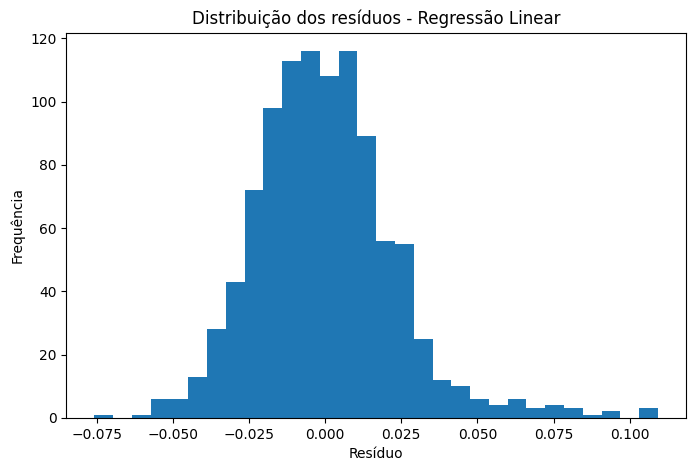

In [ ]:
# Visualizando a distribuição dos erros do modelo
plt.figure(figsize = (8, 5))
plt.hist(residuos, bins = 30)
plt.title(f"Distribuição dos resíduos - {nome_melhor_modelo}")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

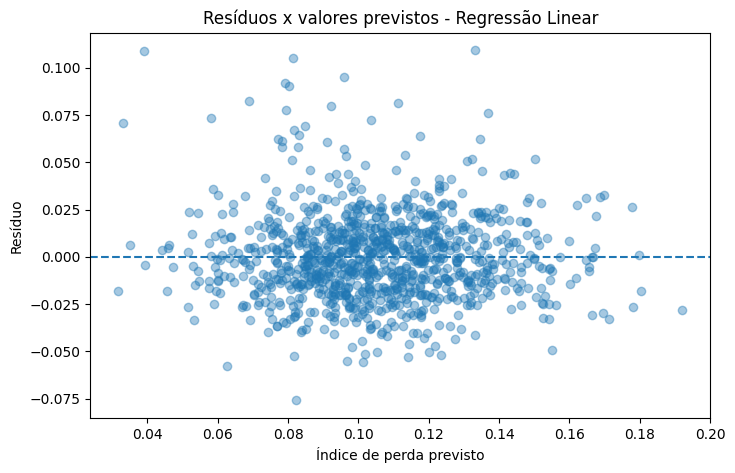

In [ ]:
# Verificando se os erros aumentam ou diminuem conforme o valor previsto
plt.figure(figsize = (8, 5))
plt.scatter(y_pred_melhor, residuos, alpha = 0.4)
plt.axhline(0, linestyle="--")

plt.title(f"Resíduos x valores previstos - {nome_melhor_modelo}")
plt.xlabel("Índice de perda previsto")
plt.ylabel("Resíduo")
plt.show()

## 6. Importância das variáveis

Para interpretar o modelo, foi utilizada permutation importance.

A técnica mede quanto o erro piora quando os valores de uma variável são embaralhados. Quanto maior a piora, maior a importância daquela variável para as previsões.

In [ ]:
# Medindo a importância das variáveis a partir da piora no erro quando cada coluna é embaralhada
importancia = permutation_importance(
    melhor_modelo,
    X_teste,
    y_teste,
    scoring="neg_mean_absolute_error",
    n_repeats = 10,
    random_state = 579
)

In [ ]:
# Organizando as importâncias em uma tabela
importancia_features = pd.DataFrame({
    "feature": X_teste.columns,
    "importancia_media": importancia.importances_mean,
    "importancia_desvio": importancia.importances_std
})

importancia_features = importancia_features.sort_values("importancia_media", ascending = False)
importancia_features.head(5)

,feature,importancia_media,importancia_desvio
6,material,0.004486,0.000340
5,necessidade_corte_ajuste,0.003912,0.000250
13,pressao_prazo,0.002676,0.000189
4,complexidade_execucao,0.002631,0.000306
3,servico,0.002539,0.000070


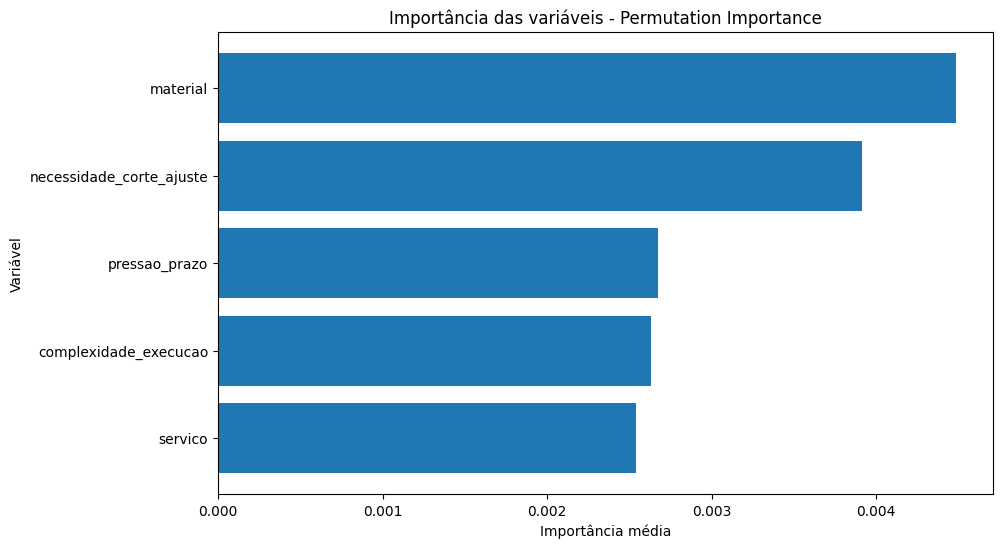

In [ ]:
# Visualizando as 5 variáveis com maior impacto no desempenho do modelo
top_features = importancia_features.head(5).sort_values("importancia_media")

plt.figure(figsize = (10, 6))
plt.barh(top_features["feature"], top_features["importancia_media"])
plt.title("Importância das variáveis - Permutation Importance")
plt.xlabel("Importância média")
plt.ylabel("Variável")
plt.show()

## 7. Salvamento do modelo

O modelo com melhor desempenho será salvo para uso posterior em simulações com novos registros de materiais.

In [ ]:
# Salvando o modelo escolhido e as informações necessárias para novas previsões
modelo_regressao = {
    "modelo": melhor_modelo,
    "features": features,
    "alvo": alvo,
    "nome_modelo": nome_melhor_modelo
}
joblib.dump(modelo_regressao, models_path / "modelo_perda_material.pkl")

['..\\models\\modelo_perda_material.pkl']

O modelo selecionado apresentou desempenho superior ao baseline baseado no índice de perda orçado.

A análise de resíduos indica que as previsões acompanham a tendência geral dos dados, embora ainda existam erros maiores em alguns registros extremos.

A análise de importância destacou principalmente `material`, `necessidade_corte_ajuste`, `pressao_prazo`, `complexidade_execucao` e `servico`, resultado coerente com a lógica do problema.

O modelo final foi salvo para uso posterior em simulações de novas previsões.